In [9]:
# Section 1: Data Processing

#This notebook loads the GTSRB dataset, preprocesses images, and prepares training and validation data.

In [10]:
# Imports 
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split

In [11]:
# Load the dataset
train_df = pd.read_csv("Train.csv")
train_df.head()


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [12]:
# preprocessing 
IMG_SIZE = 32

train_df = pd.read_csv("Train.csv")

X = []
y = []

for i in range(len(train_df)):
    img_path = train_df.loc[i, "Path"]
    label = train_df.loc[i, "ClassId"]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (39209, 32, 32, 3)
y shape: (39209,)


In [13]:
# Train/validation 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (31367, 32, 32, 3)
Validation: (7842, 32, 32, 3)


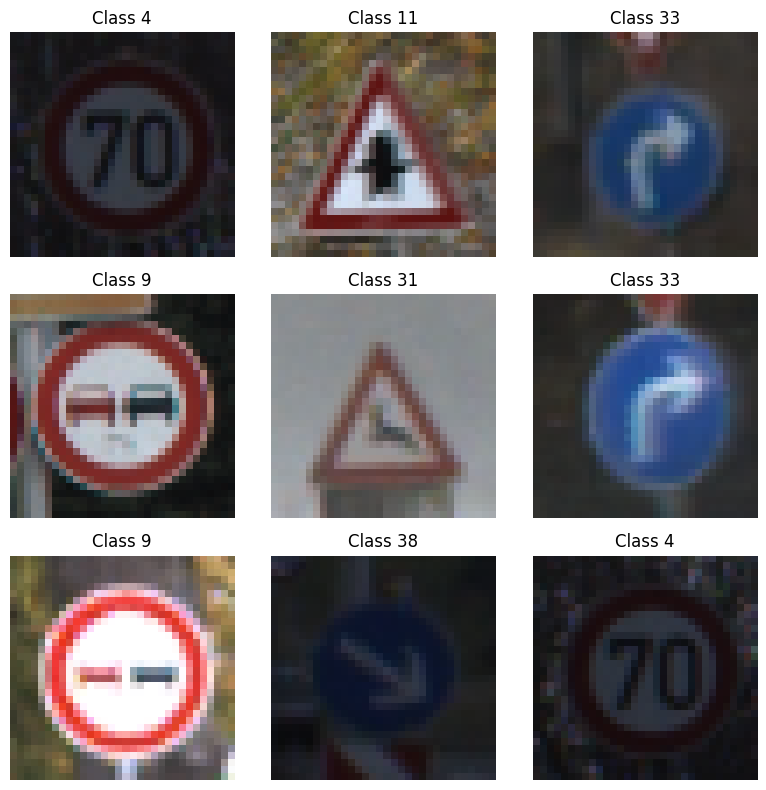

In [14]:
import random

plt.figure(figsize=(8,8))

for i in range(9):
    idx = random.randint(0, len(X_train)-1)
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[idx])
    plt.title(f"Class {y_train[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()